In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import pickle

from src.processing import (criando_cenarios_amostragem, 
                            amostrar_por_regiao,
                            treinar_surrogate,
                            prever_surrogate)

from src.visualization import (dividir_plot_regioes, 
                               adicionar_wape_por_regiao, 
                               adicionar_wape_amostragem_por_regiao,
                               plota_fitness_landscape_com_equacoes,
                               plota_landscape_cenario)

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['lines.linewidth'] = 0.5

# Surrogates
* Será construído 1 surrogate por objetivo (2).
* Os surrogates serão treinados a partir de dataframes amostrados do dataframe com a fitness lanscape completa
* Serão criadas 4 versões de cada surrogate, a partir de 4 amostras distintas da fitness landscape
* Cada cenário/amostra será gerado a partir de diferentes critérios de amostragem
    * A fitness landscape é dividida em 100 regiões de 100.000 pontos
    * Cada cenário de amostragem é representado por uma lista (100 itens) contendo a taxa % de amostragem por regiao
* Feature Engineering: No final desse notebook \/ encontra-se um backlog de ideias e codigo de Feature Engineering

In [2]:
df  = pd.read_parquet('data/df_problema1.parquet')
df2 = pd.read_parquet('data/df_problema2.parquet')

# divide landscape em N regiões
n_regioes = 10
df['regiao'] = pd.cut(df['registro'], bins=n_regioes, labels=False) + 1
df['regiao'] = df['regiao'].astype(str)

df2['regiao'] = pd.cut(df2['registro'], bins=n_regioes, labels=False) + 1
df2['regiao'] = df2['regiao'].astype(str)

* Na análise abaixo observamos que as eq0 e eq2 nao podem ser utilizadas como features, pois por terem periodo muito longo, o modelo conseguiria capturar uma relacao linear feature <> registro <> fitness e conseguiria criar um modelo perfeito.

fitness1    3.002385
fitness2    3.000001
dtype: float64


/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


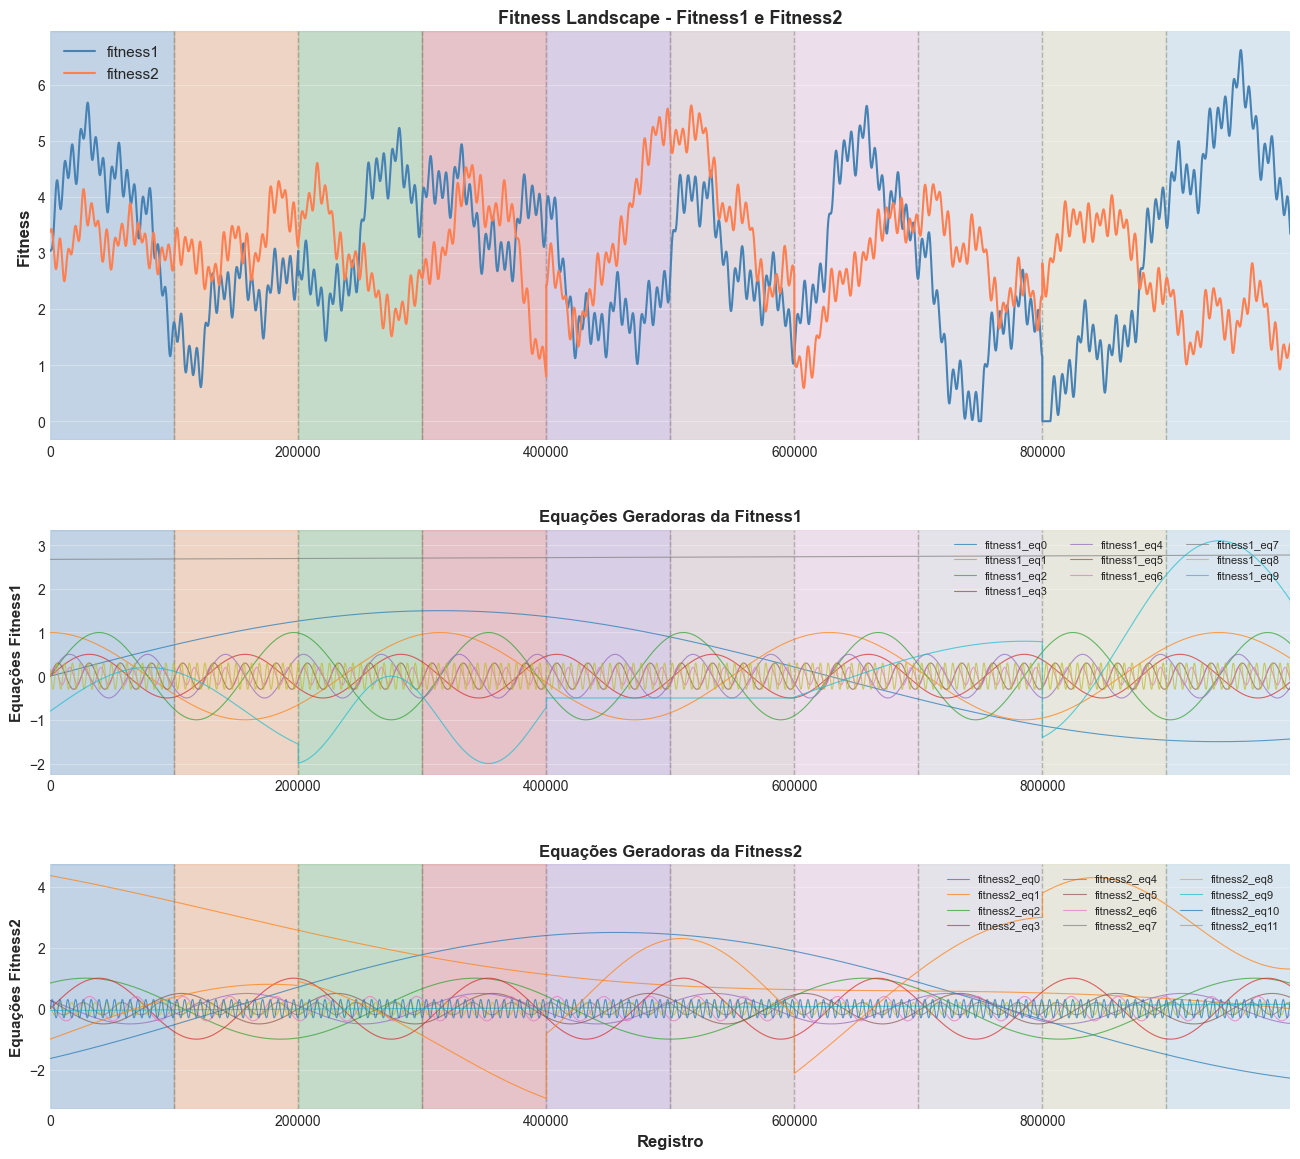

In [3]:
# Plota fitness landscape com equações geradoras em 3 subplots
print(df[['fitness1','fitness2']].mean())
plota_fitness_landscape_com_equacoes(df, n_regioes)

#### Cenários de Amostragem
* 1) homogêneo: todas as 100 regiões com a mesma taxa de amostragem
* 2) fácil: regiões com ótimos verdadeiros e fitness_full média alta recebe MAIOR taxa % de amostragem (proporcional)
* 3) difícil: regiões com ótimos verdadeiros e fitness_full média alta recebe MENOR taxa % de amostragem (inversamente proporcional)

In [4]:
# define parametros para criacao de cenários de amostragem
taxa_amostragem_global = 0.3
proporcionalidade = 15

# definindo cenários de amostragem
df_amostragem1 = criando_cenarios_amostragem(df, 
                                taxa_amostragem_global,
                                n_regioes,
                                proporcionalidade)

df_amostragem2 = criando_cenarios_amostragem(df2, 
                                taxa_amostragem_global,
                                n_regioes,
                                proporcionalidade)

# realizando amostragem por cenário
df_cenario1 = amostrar_por_regiao(df, df_amostragem1, 'cenario1')
df_cenario2 = amostrar_por_regiao(df, df_amostragem1, 'cenario2')
df_cenario3 = amostrar_por_regiao(df, df_amostragem1, 'cenario3')

df_cenario1_p2 = amostrar_por_regiao(df2, df_amostragem2, 'cenario1')
df_cenario2_p2 = amostrar_por_regiao(df2, df_amostragem2, 'cenario2')
df_cenario3_p2 = amostrar_por_regiao(df2, df_amostragem2, 'cenario3')


taxa % amostragem média


cenario1    0.300000
cenario2    0.385398
cenario3    0.440877
dtype: float64

taxa % amostragem média


cenario1    0.300000
cenario2    0.411963
cenario3    0.377057
dtype: float64

In [5]:
print(df.shape)
print(df_cenario1.shape)
print(df_cenario2.shape)
print(df_cenario3.shape)

print(df2.shape)
print(df_cenario1_p2.shape)
print(df_cenario2_p2.shape)
print(df_cenario3_p2.shape)

ams1 = df_cenario1.groupby('regiao').size().reset_index(name = 'cenario1')
ams2 = df_cenario2.groupby('regiao').size().reset_index(name = 'cenario2')
ams3 = df_cenario3.groupby('regiao').size().reset_index(name = 'cenario3')

ams1_p2 = df_cenario1_p2.groupby('regiao').size().reset_index(name = 'cenario1_p2')
ams2_p2 = df_cenario2_p2.groupby('regiao').size().reset_index(name = 'cenario2_p2')
ams3_p2 = df_cenario3_p2.groupby('regiao').size().reset_index(name = 'cenario3_p2')

teste = (ams1.merge(ams2,    on='regiao', how='outer').
              merge(ams3,    on='regiao', how='outer').
              merge(ams1_p2, on='regiao', how='outer').
              merge(ams2_p2, on='regiao', how='outer').
              merge(ams3_p2, on='regiao', how='outer')
        )

display(px.line(df_amostragem1, x='regiao', y=['fitness_full', 'fitness1', 'fitness2','desvio_media'], markers=True))
display(px.line(df_amostragem1, x='regiao', y=['cenario1', 'cenario2', 'cenario3'], markers=True))
display(px.line(df_amostragem2, x='regiao', y=['cenario1', 'cenario2', 'cenario3'], markers=True))
display(px.line(teste,          x='regiao', y=['cenario1', 'cenario2', 'cenario3', 'cenario1_p2', 'cenario2_p2', 'cenario3_p2'], markers=True))

(1000000, 27)
(300000, 27)
(385396, 27)
(440875, 27)
(1000000, 31)
(300000, 31)
(411959, 31)
(377055, 31)


## Treinamento de Surrogates

#### 1. Problema 1

In [6]:
colunas_categoricas    = []#['regiao']
target_surrogate1      = 'fitness1'
features_surrogate1_p1 = [#'regiao',
#                          'fitness1_eq0',  # equacao linear por regiao (gera modelo perfeito)
#                          'fitness1_eq1',  # ''
#                          'fitness1_eq7',  # ''
#                          'fitness1_eq8',  # ''
#                          'fitness1_eq2',  # muito correlacionada com fitness 1, vai ser uma feature boa demais
                          'fitness1_eq3', 
                          'fitness1_eq4',  
                          'fitness1_eq5',  
                          'fitness1_eq6', 
                          ]
                       
s1, s2, s3 = treinar_surrogate(df_cenario1, df_cenario2, df_cenario3,
                               features_surrogate1_p1, target_surrogate1, colunas_categoricas)

# Salvar modelo s1
with open('data/model_surrogate1_p1.pkl', 'wb') as f:
    pickle.dump(s1, f)
print("Modelo s1 salvo em data/model_surrogate1_p1.pkl")

df4 = prever_surrogate(df, features_surrogate1_p1, 1, s1, s2, s3)

Treinando CatBoost com 4 features...
Total de observações: 300000
0:	learn: 1.3473643	total: 63.7ms	remaining: 1m 3s
999:	learn: 1.1954607	total: 6.41s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness1_eq3   43.685995
1  fitness1_eq4   28.127431
3  fitness1_eq6   15.379261
2  fitness1_eq5   12.807314
Treinando CatBoost com 4 features...
Total de observações: 385396
0:	learn: 1.0783345	total: 10ms	remaining: 10s
999:	learn: 0.9027530	total: 7.64s	remaining: 0us
--- Feature importance ---
        feature  importance
1  fitness1_eq4   39.144948
0  fitness1_eq3   31.198428
2  fitness1_eq5   16.983002
3  fitness1_eq6   12.673623
Treinando CatBoost com 4 features...
Total de observações: 440875
0:	learn: 0.9968526	total: 11ms	remaining: 11s
999:	learn: 0.8118778	total: 8.59s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness1_eq3   46.976756
1  fitness1_eq4   20.874524
3  fitness1_eq6   17.185916
2  fitness1_eq5   14.962804
Modelo

In [7]:
colunas_categoricas    = []
target_surrogate2      = 'fitness2'
features_surrogate2_p1 = ['fitness2_eq4', 
                          'fitness2_eq5',  
                          'fitness2_eq6',  
                          'fitness2_eq7', 
                          'fitness2_eq8', 
                          ]
                       
s4, s5, s6 = treinar_surrogate(df_cenario1, df_cenario2, df_cenario3,
                               features_surrogate2_p1, target_surrogate2, colunas_categoricas)

# Salvar modelo s4
with open('data/model_surrogate2_p1.pkl', 'wb') as f:
    pickle.dump(s4, f)
print("Modelo s4 salvo em data/model_surrogate2_p1.pkl")

df5 = prever_surrogate(df4, features_surrogate2_p1, 2, s4, s5, s6)

Treinando CatBoost com 5 features...
Total de observações: 300000
0:	learn: 0.9156181	total: 7.53ms	remaining: 7.52s
999:	learn: 0.7170618	total: 7.27s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness2_eq4   37.868260
1  fitness2_eq5   33.481947
2  fitness2_eq6   13.668932
3  fitness2_eq7   12.608319
4  fitness2_eq8    2.372543
Treinando CatBoost com 5 features...
Total de observações: 385396
0:	learn: 0.7604555	total: 11.4ms	remaining: 11.4s
999:	learn: 0.4547942	total: 8.64s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness2_eq4   34.733831
1  fitness2_eq5   33.578812
2  fitness2_eq6   17.711012
3  fitness2_eq7   12.029795
4  fitness2_eq8    1.946550
Treinando CatBoost com 5 features...
Total de observações: 440875
0:	learn: 0.9699153	total: 11.8ms	remaining: 11.8s
999:	learn: 0.6150427	total: 9.29s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness2_eq4   42.747075
1  fitness2_eq5   27.79261

In [8]:
df5.to_parquet('data/df_surrogate1.parquet')

#### 2. Problema 2

In [9]:
colunas_categoricas    = []#['regiao']
target_surrogate1      = 'fitness1'
features_surrogate1_p2 = [#'regiao',
                          'fitness1_eq6', 
                          'fitness1_eq7',  
                          'fitness1_eq8',  
                          'fitness1_eq9',  
                          ]
                       
s1, s2, s3 = treinar_surrogate(df_cenario1_p2, df_cenario2_p2, df_cenario3_p2,
                               features_surrogate1_p2, target_surrogate1, colunas_categoricas)

# Salvar modelo s1
with open('data/model_surrogate1_p2.pkl', 'wb') as f:
    pickle.dump(s1, f)
print("Modelo s1 salvo em data/model_surrogate1_p2.pkl")

df6 = prever_surrogate(df2, features_surrogate1_p2, 1, s1, s2, s3)

Treinando CatBoost com 4 features...
Total de observações: 300000
0:	learn: 2.5438265	total: 7.84ms	remaining: 7.84s
999:	learn: 2.0382592	total: 7.05s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness1_eq6   52.312613
1  fitness1_eq7   22.091374
2  fitness1_eq8   19.293217
3  fitness1_eq9    6.302795
Treinando CatBoost com 4 features...
Total de observações: 411959
0:	learn: 1.7132589	total: 10.2ms	remaining: 10.2s
999:	learn: 0.9378448	total: 8.53s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness1_eq6   47.058788
2  fitness1_eq8   24.091121
1  fitness1_eq7   23.374459
3  fitness1_eq9    5.475632
Treinando CatBoost com 4 features...
Total de observações: 377055
0:	learn: 2.3619468	total: 9.49ms	remaining: 9.48s
999:	learn: 1.9016988	total: 7.5s	remaining: 0us
--- Feature importance ---
        feature  importance
0  fitness1_eq6   47.135250
1  fitness1_eq7   23.428838
2  fitness1_eq8   23.268829
3  fitness1_eq9    6.167083

In [10]:
colunas_categoricas    = []
target_surrogate2      = 'fitness2'
features_surrogate2_p2 = ['fitness1_eq6',
                          'fitness1_eq7',
                          'fitness1_eq8',
                          'fitness1_eq9',
                          'fitness1_eq10',
                          ]
                       
s4, s5, s6 = treinar_surrogate(df_cenario1_p2, df_cenario2_p2, df_cenario3_p2,
                               features_surrogate2_p2, target_surrogate2, colunas_categoricas)

# Salvar modelo s4
with open('data/model_surrogate2_p2.pkl', 'wb') as f:
    pickle.dump(s4, f)
print("Modelo s4 salvo em data/model_surrogate2_p2.pkl")

df7 = prever_surrogate(df6, features_surrogate2_p2, 2, s4, s5, s6)

Treinando CatBoost com 5 features...
Total de observações: 300000
0:	learn: 2.3981635	total: 8.04ms	remaining: 8.03s
999:	learn: 1.9032364	total: 6.96s	remaining: 0us
--- Feature importance ---
         feature  importance
0   fitness1_eq6   60.079267
1   fitness1_eq7   15.189977
4  fitness1_eq10   14.037524
2   fitness1_eq8    7.036143
3   fitness1_eq9    3.657089
Treinando CatBoost com 5 features...
Total de observações: 411959
0:	learn: 2.2670736	total: 9.81ms	remaining: 9.8s
999:	learn: 1.6427046	total: 8.91s	remaining: 0us
--- Feature importance ---
         feature  importance
0   fitness1_eq6   55.954722
1   fitness1_eq7   14.370425
4  fitness1_eq10   13.994694
2   fitness1_eq8   12.026507
3   fitness1_eq9    3.653652
Treinando CatBoost com 5 features...
Total de observações: 377055
0:	learn: 2.5055721	total: 9.01ms	remaining: 9s
999:	learn: 1.9703431	total: 8.33s	remaining: 0us
--- Feature importance ---
         feature  importance
0   fitness1_eq6   54.337878
1   fitness1_eq7

In [11]:
df7.to_parquet('data/df_surrogate2.parquet')

#### Estudo/Análise:
- curva WAPE vs. taxa % de amostragem global (4 curvas para cada um dos 4 cenários)
    - e assim define nível de amostragem, de forma que os modelos tenham WAPE 15
    - wape de sub/sobre estimativa
    - distribuicoes

/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:779: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



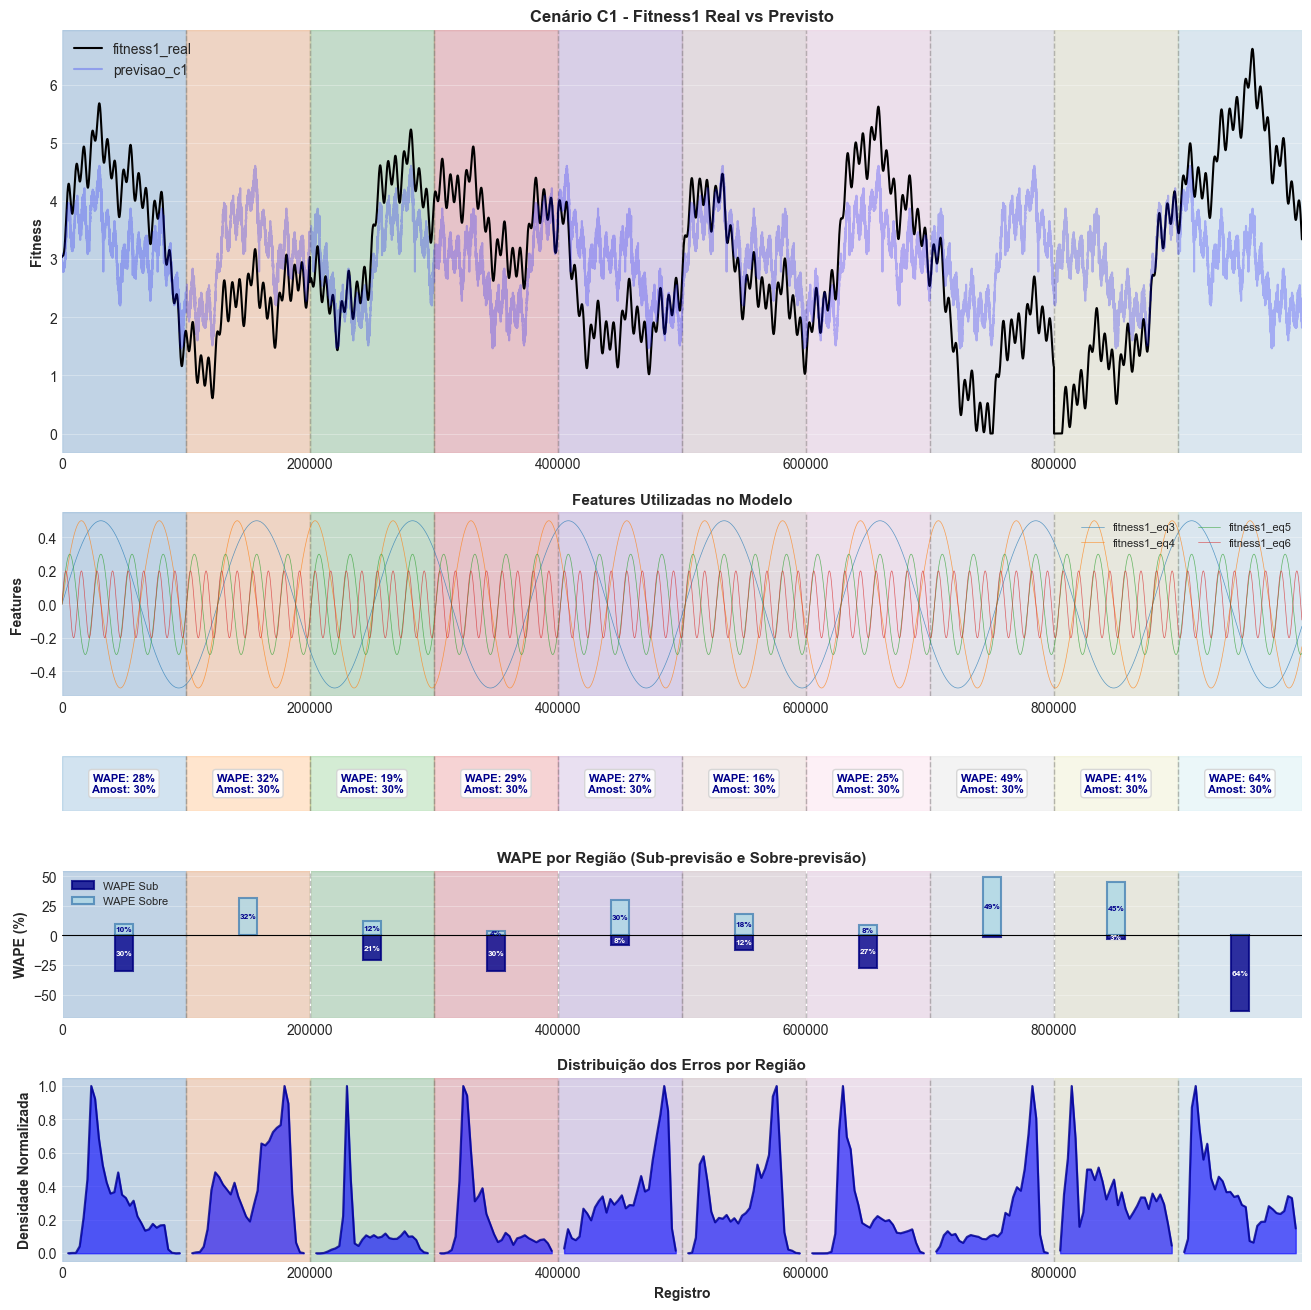

/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:779: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



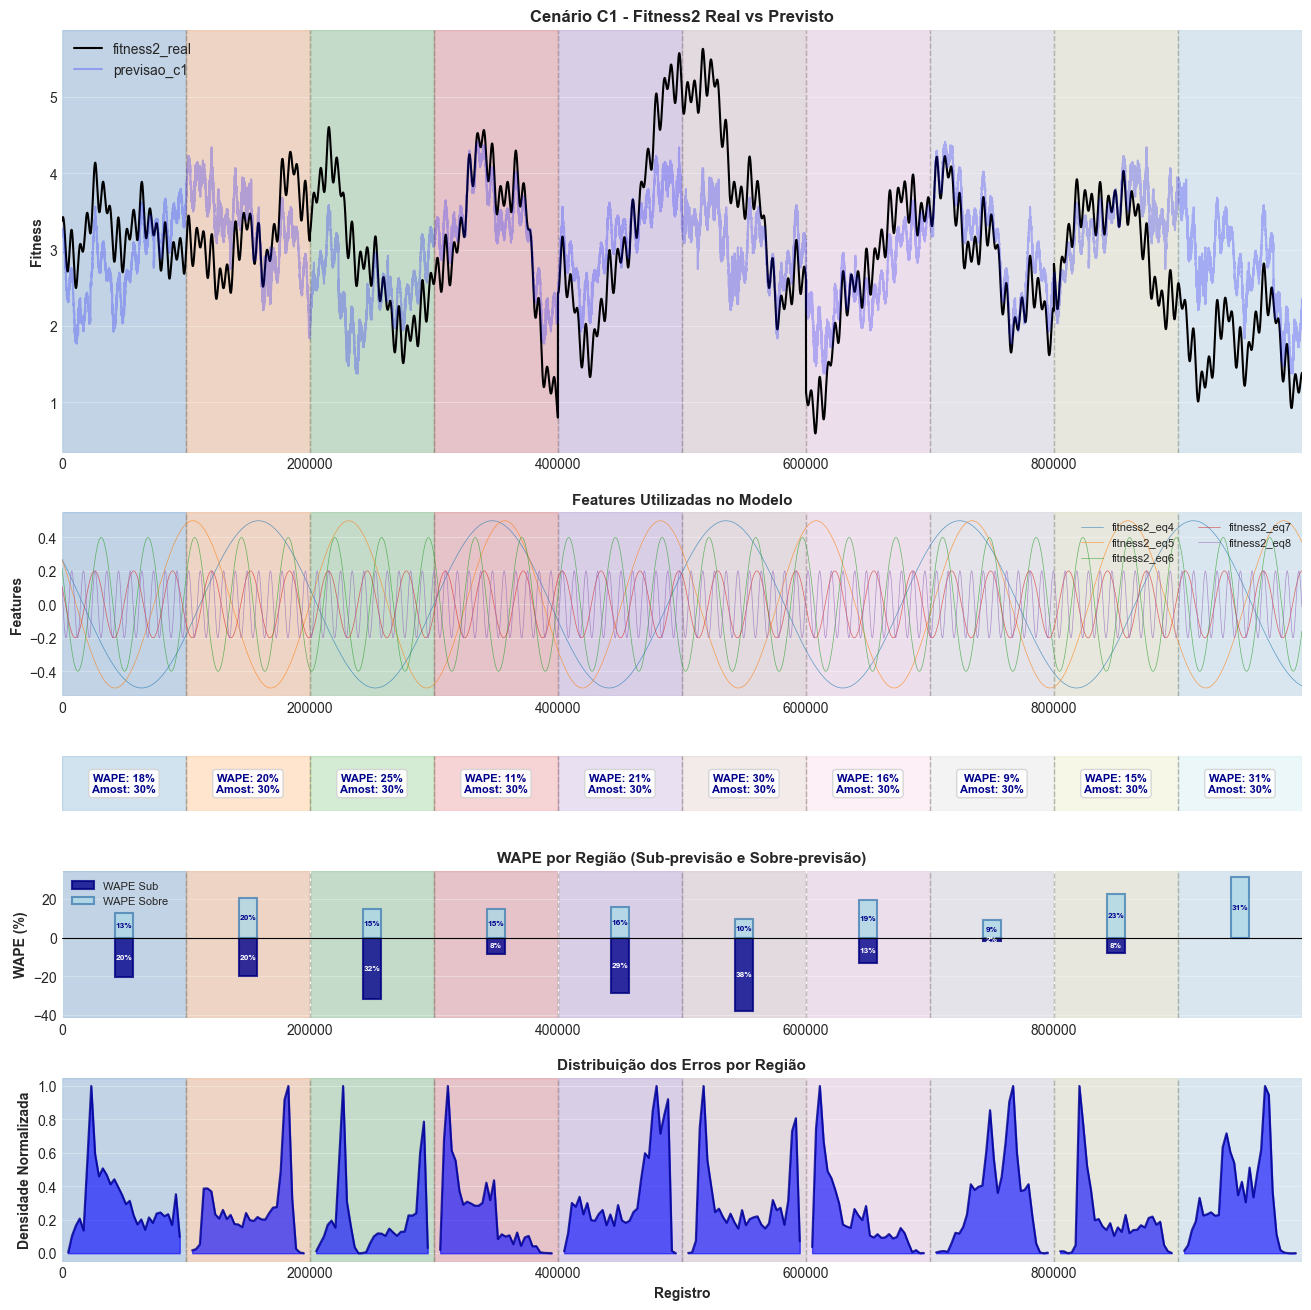

/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:779: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



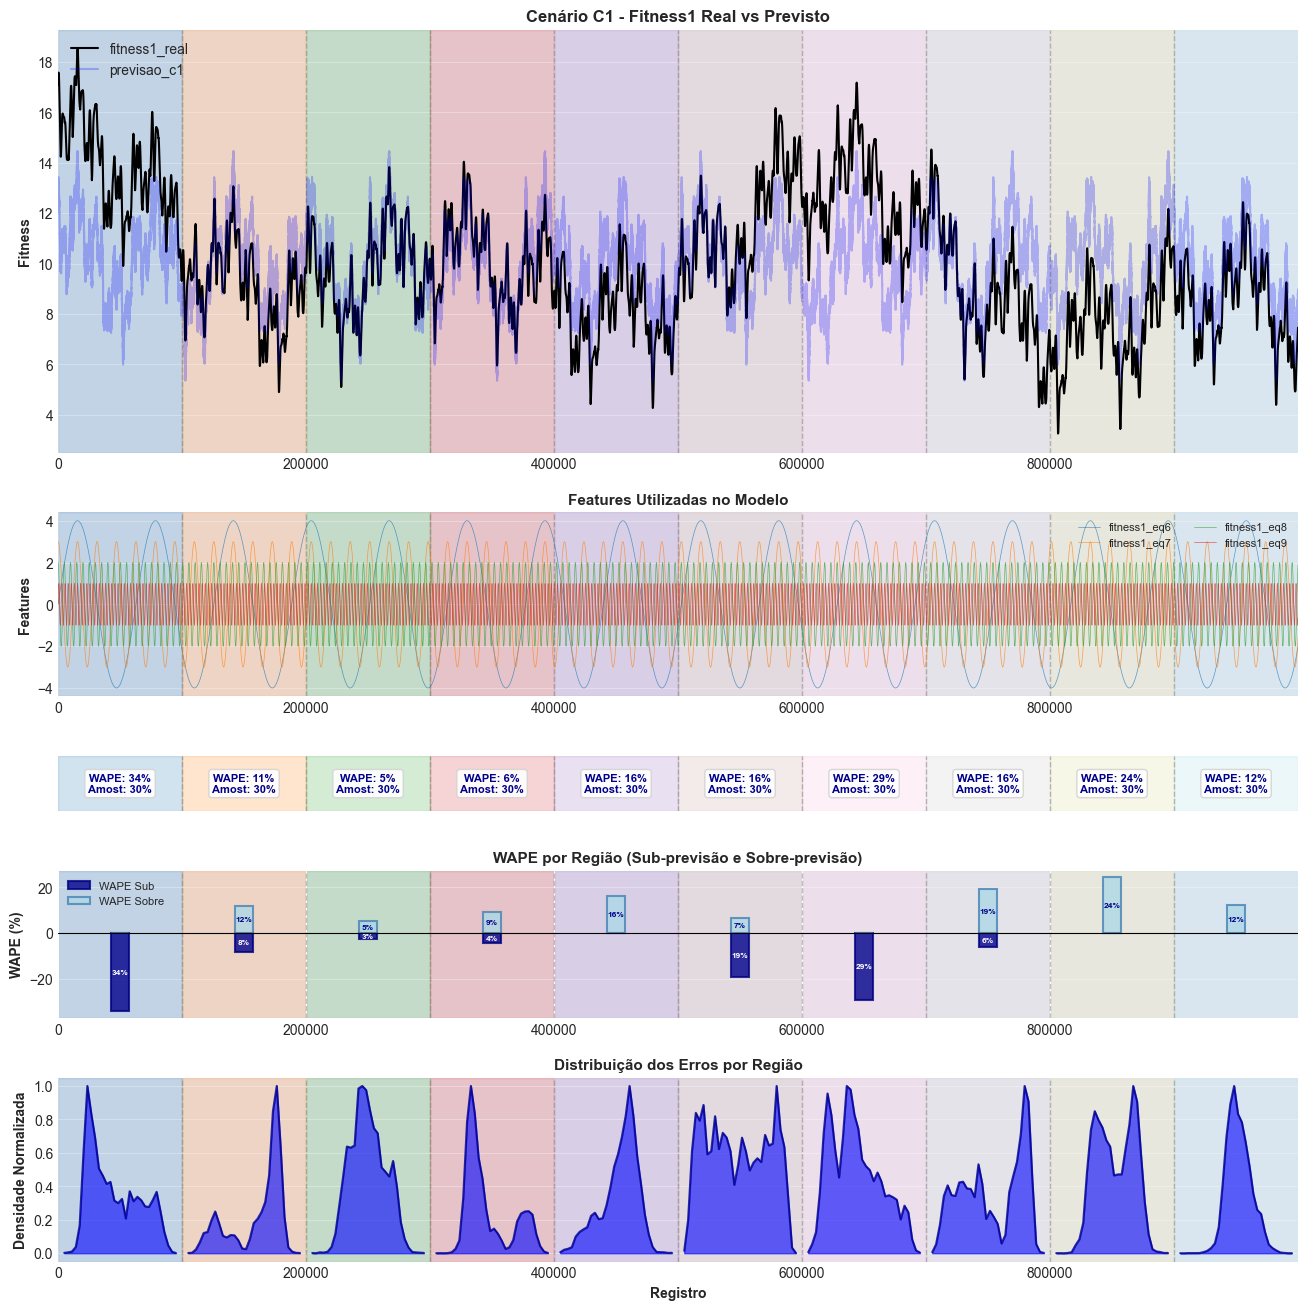

/Users/gmello/Documents/python_repos/mestrado/ua-dd-saea/src/visualization.py:779: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



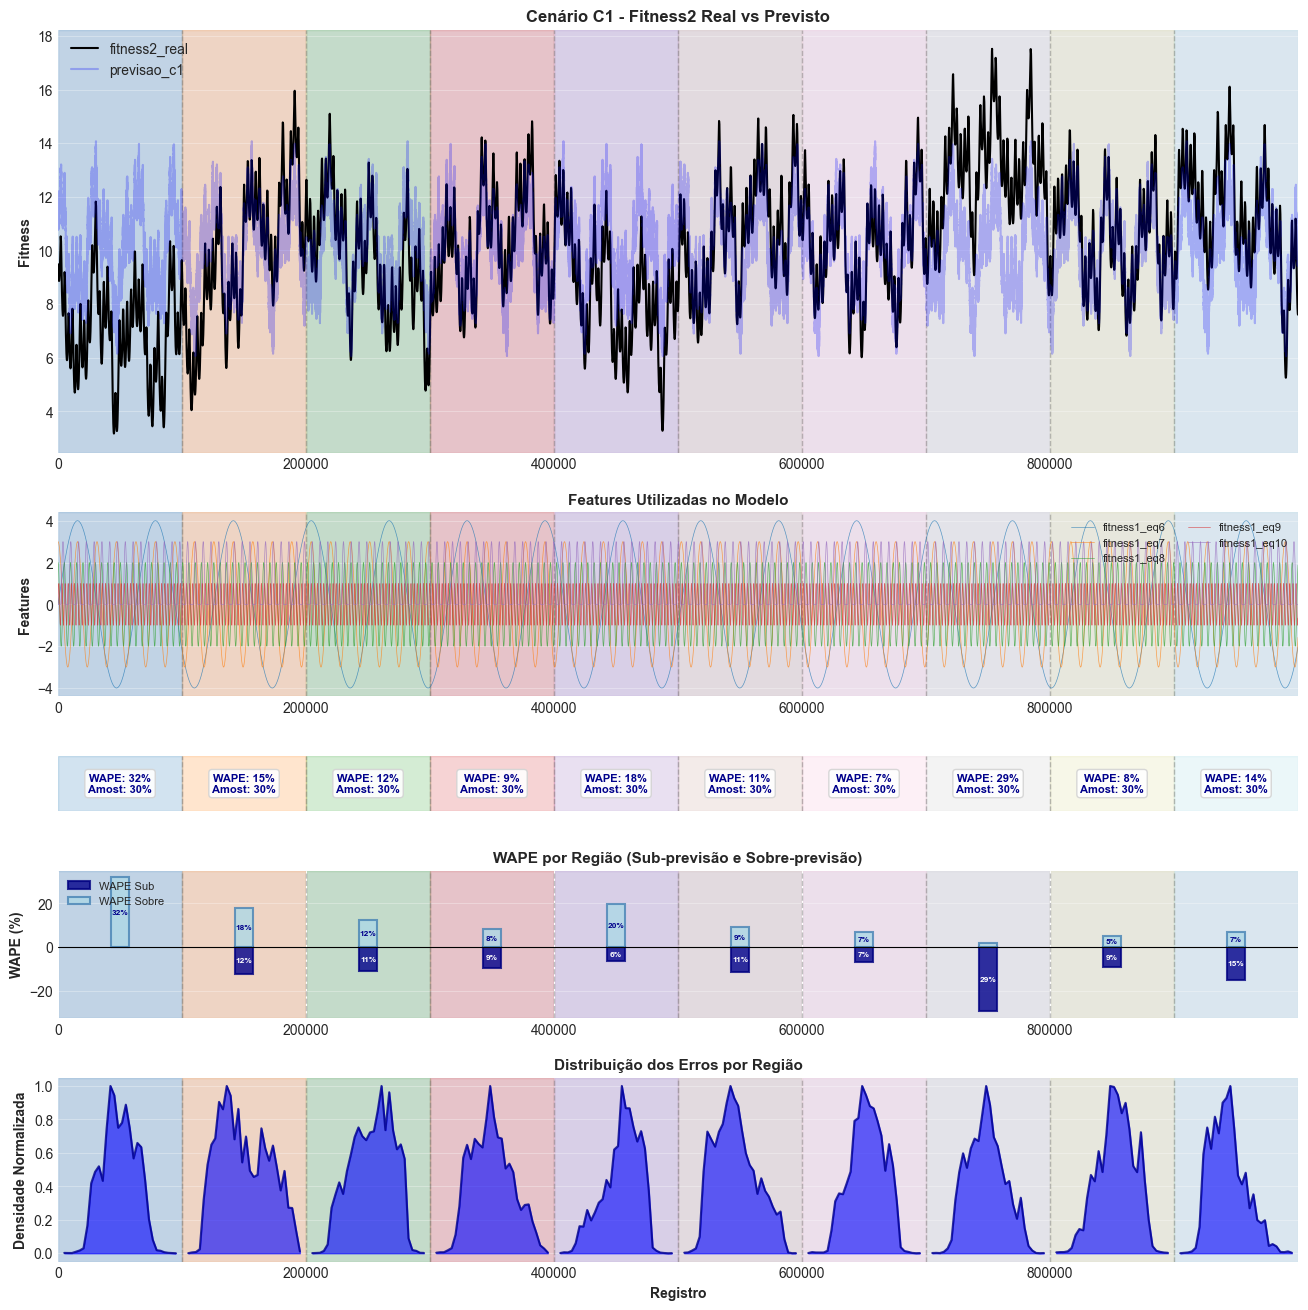

In [12]:
################# Problema 1 #################
# Cenário 1 - Fitness 1 e 2
plota_landscape_cenario(df5, features_surrogate1_p1, df_amostragem1, cenario='c1', fitness_num=1)
plota_landscape_cenario(df5, features_surrogate2_p1, df_amostragem1, cenario='c1', fitness_num=2)

## Cenário 2 - Fitness 1
#plota_landscape_cenario(df5, features_surrogate1, df_amostragem, cenario='c2', fitness_num=1)
#
## Cenário 3 - Fitness 1
#plota_landscape_cenario(df5, features_surrogate1, df_amostragem, cenario='c3', fitness_num=1)


################# Problema 2 #################
# Cenário 1 - Fitness 1 e 2
plota_landscape_cenario(df7, features_surrogate1_p2, df_amostragem2, cenario='c1', fitness_num=1)
plota_landscape_cenario(df7, features_surrogate2_p2, df_amostragem2, cenario='c1', fitness_num=2)

#### Análise de Correlação: Amostragem vs. Métricas de Erro (WAPE e RMSE)

* Objetivo: Analisar a relação entre taxa de amostragem por região e as métricas de erro (WAPE e RMSE)
* Visualizações:
    * 3 Heatmaps lado a lado: Taxa de Amostragem, WAPE e RMSE (linhas=cenários, colunas=regiões)
    * 3 Gráficos de linha: Um por cenário, mostrando Taxa de Amostragem, WAPE e RMSE por região
    * Análise de correlação entre amostragem e métricas de erro


In [13]:
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# Configurações
max_registro = df4['registro'].max()

# Função para calcular métricas por região e cenário
def calcular_metricas_matriz(df, cenarios, df_amostragem):
    """
    Calcula matrizes de taxa de amostragem, WAPE e RMSE
    Retorna 3 matrizes 3x5 (cenários x regiões)
    
    IMPORTANTE: WAPE por região = mean(abs(erro da região)) / mean(realizado de toda a base)
    """
    taxa_amostragem_matriz = []
    wape_matriz = []
    rmse_matriz = []
    
    for cenario in cenarios:
        col_previsto = f'fitness1_{cenario}'
        col_cenario_amost = f'cenario{cenario[-1]}'  # 'c1' -> 'cenario1'
        
        # Calcular denominador global (média de toda a base)
        denominador_global = df['fitness1'].mean()
        
        taxas_regiao = []
        wapes_regiao = []
        rmses_regiao = []
        
        for i in range(n_regioes):
            # Definir limites da região
            inicio = i * (1 / n_regioes) * max_registro
            fim = (i + 1) * (1 / n_regioes) * max_registro
            
            # Filtrar dados da região
            df_regiao = df[(df['registro'] >= inicio) & (df['registro'] < fim)]
            
            # Taxa de amostragem
            taxa = df_amostragem.loc[i, col_cenario_amost] * 100
            taxas_regiao.append(taxa)
            
            # WAPE: mean(abs(erro da região)) / mean(real de toda a base)
            erros = df_regiao[col_previsto] - df_regiao['fitness1']
            erro_abs = np.abs(erros)
            wape = 100 * erro_abs.mean() / denominador_global
            wapes_regiao.append(wape)
            
            # RMSE
            rmse = np.sqrt(np.mean(erros**2))
            rmses_regiao.append(rmse)
        
        taxa_amostragem_matriz.append(taxas_regiao)
        wape_matriz.append(wapes_regiao)
        rmse_matriz.append(rmses_regiao)
    
    return np.array(taxa_amostragem_matriz), np.array(wape_matriz), np.array(rmse_matriz)

# Calcular as 3 matrizes
cenarios = ['c1', 'c2', 'c3']
taxa_matriz, wape_matriz, rmse_matriz = calcular_metricas_matriz(df4, cenarios, df_amostragem)

# Criar DataFrames para melhor visualização
regioes_labels = ['Região 1', 'Região 2', 'Região 3', 'Região 4', 'Região 5']
cenarios_labels = ['Cenário 1', 'Cenário 2', 'Cenário 3']

df_taxa = pd.DataFrame(taxa_matriz, index=cenarios_labels, columns=regioes_labels)
df_wape = pd.DataFrame(wape_matriz, index=cenarios_labels, columns=regioes_labels)
df_rmse = pd.DataFrame(rmse_matriz, index=cenarios_labels, columns=regioes_labels)

print("Matriz de Taxa de Amostragem (%):")
print(df_taxa.round(1))
print("\nMatriz de WAPE (%):")
print(df_wape.round(1))
print("\nMatriz de RMSE:")
print(df_rmse.round(2))


NameError: name 'df_amostragem' is not defined

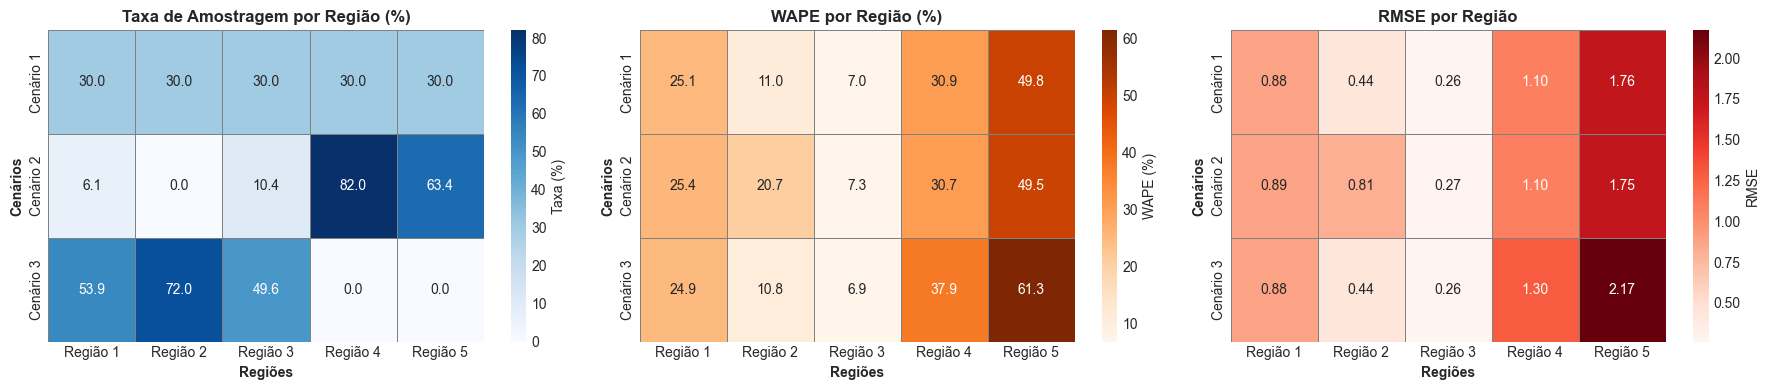

In [ ]:
# ============================================================
# VISUALIZAÇÃO 1: 3 Heatmaps lado a lado
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Heatmap 1: Taxa de Amostragem
sns.heatmap(df_taxa, annot=True, fmt='.1f', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Taxa (%)'}, linewidths=0.5, linecolor='gray')
axes[0].set_title('Taxa de Amostragem por Região (%)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Cenários', fontweight='bold')
axes[0].set_xlabel('Regiões', fontweight='bold')

# Heatmap 2: WAPE
sns.heatmap(df_wape, annot=True, fmt='.1f', cmap='Oranges', ax=axes[1], 
            cbar_kws={'label': 'WAPE (%)'}, linewidths=0.5, linecolor='gray')
axes[1].set_title('WAPE por Região (%)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Cenários', fontweight='bold')
axes[1].set_xlabel('Regiões', fontweight='bold')

# Heatmap 3: RMSE
sns.heatmap(df_rmse, annot=True, fmt='.2f', cmap='Reds', ax=axes[2], 
            cbar_kws={'label': 'RMSE'}, linewidths=0.5, linecolor='gray')
axes[2].set_title('RMSE por Região', fontweight='bold', fontsize=12)
axes[2].set_ylabel('Cenários', fontweight='bold')
axes[2].set_xlabel('Regiões', fontweight='bold')

plt.tight_layout()
plt.show()


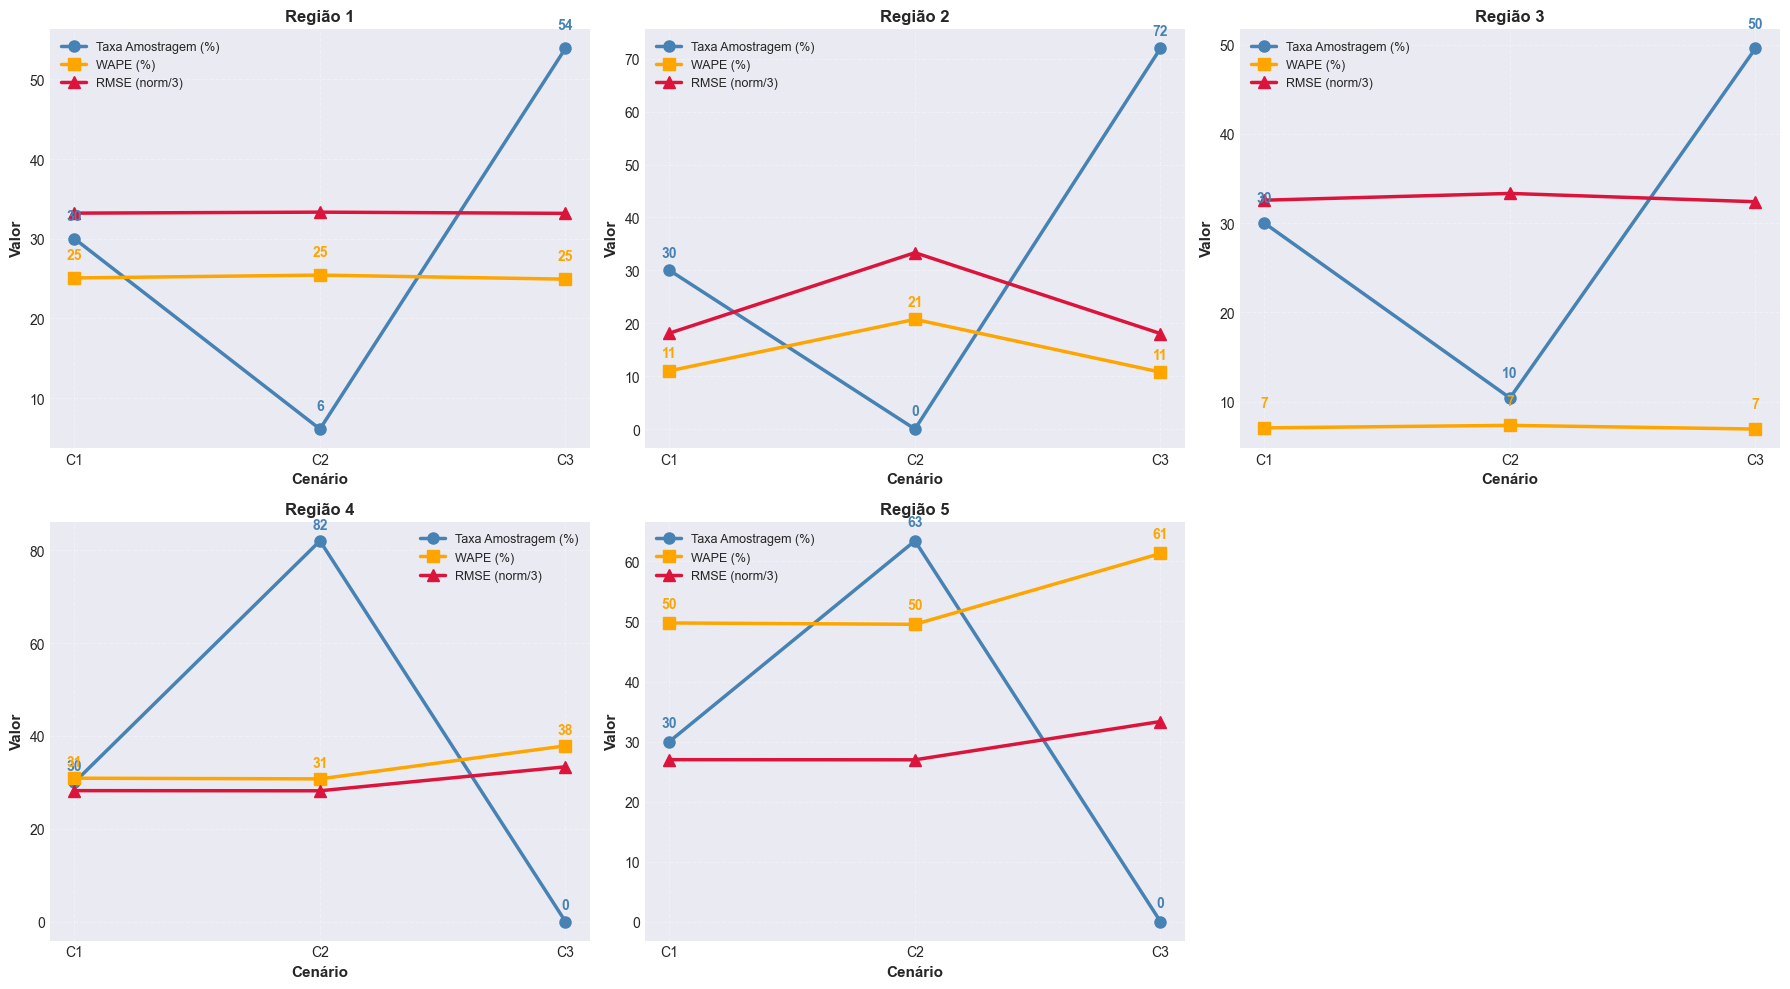


Observação: RMSE foi normalizado para escala 0-100 e dividido por 3 para comparação visual próxima ao WAPE.


In [ ]:
# ============================================================
# VISUALIZAÇÃO 2: 5 Gráficos de linha (um por região)
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # Achatar para facilitar iteração

cenarios_num = [1, 2, 3]

for regiao_idx in range(5):
    ax = axes[regiao_idx]
    
    # Dados da região (através dos 3 cenários)
    taxas = taxa_matriz[:, regiao_idx]  # Pega coluna da região para todos os cenários
    wapes = wape_matriz[:, regiao_idx]
    rmses = rmse_matriz[:, regiao_idx]
    
    # Normalizar RMSE para escala 0-100 e dividir por 3 para ficar próximo do WAPE
    rmses_norm = ((rmses / rmses.max()) * 100 / 3) if rmses.max() > 0 else rmses
    
    # Plotar as 3 linhas
    ax.plot(cenarios_num, taxas, marker='o', linewidth=2.5, markersize=8, 
            label='Taxa Amostragem (%)', color='steelblue')
    ax.plot(cenarios_num, wapes, marker='s', linewidth=2.5, markersize=8, 
            label='WAPE (%)', color='orange')
    ax.plot(cenarios_num, rmses_norm, marker='^', linewidth=2.5, markersize=8, 
            label='RMSE (norm/3)', color='crimson')
    
    # Configurações
    ax.set_xlabel('Cenário', fontweight='bold', fontsize=11)
    ax.set_ylabel('Valor', fontweight='bold', fontsize=11)
    ax.set_title(f'Região {regiao_idx + 1}', fontweight='bold', fontsize=12)
    ax.set_xticks(cenarios_num)
    ax.set_xticklabels([f'C{i}' for i in cenarios_num])
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Adicionar valores nas linhas (fonte maior)
    for i, (c, t, w, rm) in enumerate(zip(cenarios_num, taxas, wapes, rmses_norm)):
        ax.text(c, t + 2, f'{t:.0f}', ha='center', va='bottom', fontsize=10, 
                color='steelblue', fontweight='bold')
        ax.text(c, w + 2, f'{w:.0f}', ha='center', va='bottom', fontsize=10, 
                color='orange', fontweight='bold')

# Remover o último subplot (posição 6) que não será usado
axes[5].axis('off')

plt.tight_layout()
plt.show()

print("\nObservação: RMSE foi normalizado para escala 0-100 e dividido por 3 para comparação visual próxima ao WAPE.")


In [ ]:
# ============================================================
# ANÁLISE DE CORRELAÇÃO
# ============================================================

# Achatar as matrizes para calcular correlação geral
taxa_flat = taxa_matriz.flatten()
wape_flat = wape_matriz.flatten()
rmse_flat = rmse_matriz.flatten()

# Calcular correlações
corr_pearson_taxa_wape, p_pearson_taxa_wape = pearsonr(taxa_flat, wape_flat)
corr_spearman_taxa_wape, p_spearman_taxa_wape = spearmanr(taxa_flat, wape_flat)

corr_pearson_taxa_rmse, p_pearson_taxa_rmse = pearsonr(taxa_flat, rmse_flat)
corr_spearman_taxa_rmse, p_spearman_taxa_rmse = spearmanr(taxa_flat, rmse_flat)

print("="*70)
print("ANÁLISE DE CORRELAÇÃO: Taxa de Amostragem vs. Métricas de Erro")
print("="*70)

print("\n📊 CORRELAÇÃO: Taxa de Amostragem vs. WAPE")
print(f"   • Pearson:  r = {corr_pearson_taxa_wape:.4f}  (p-value = {p_pearson_taxa_wape:.4f})")
print(f"   • Spearman: ρ = {corr_spearman_taxa_wape:.4f}  (p-value = {p_spearman_taxa_wape:.4f})")

if abs(corr_pearson_taxa_wape) > 0.7:
    print(f"   ➡️ Correlação FORTE {'negativa' if corr_pearson_taxa_wape < 0 else 'positiva'}")
elif abs(corr_pearson_taxa_wape) > 0.4:
    print(f"   ➡️ Correlação MODERADA {'negativa' if corr_pearson_taxa_wape < 0 else 'positiva'}")
else:
    print(f"   ➡️ Correlação FRACA {'negativa' if corr_pearson_taxa_wape < 0 else 'positiva'}")

print("\n📊 CORRELAÇÃO: Taxa de Amostragem vs. RMSE")
print(f"   • Pearson:  r = {corr_pearson_taxa_rmse:.4f}  (p-value = {p_pearson_taxa_rmse:.4f})")
print(f"   • Spearman: ρ = {corr_spearman_taxa_rmse:.4f}  (p-value = {p_spearman_taxa_rmse:.4f})")

if abs(corr_pearson_taxa_rmse) > 0.7:
    print(f"   ➡️ Correlação FORTE {'negativa' if corr_pearson_taxa_rmse < 0 else 'positiva'}")
elif abs(corr_pearson_taxa_rmse) > 0.4:
    print(f"   ➡️ Correlação MODERADA {'negativa' if corr_pearson_taxa_rmse < 0 else 'positiva'}")
else:
    print(f"   ➡️ Correlação FRACA {'negativa' if corr_pearson_taxa_rmse < 0 else 'positiva'}")

print("\n" + "="*70)
print("INTERPRETAÇÃO:")
print("="*70)
print("• Correlação negativa indica que MAIOR amostragem → MENOR erro")
print("• Correlação positiva indica que MAIOR amostragem → MAIOR erro")
print("• |r| < 0.3: fraca | 0.3-0.7: moderada | > 0.7: forte")
print("• p-value < 0.05: estatisticamente significativo")
print("="*70)


ANÁLISE DE CORRELAÇÃO: Taxa de Amostragem vs. Métricas de Erro

📊 CORRELAÇÃO: Taxa de Amostragem vs. WAPE
   • Pearson:  r = -0.1409  (p-value = 0.6165)
   • Spearman: ρ = -0.1935  (p-value = 0.4896)
   ➡️ Correlação FRACA negativa

📊 CORRELAÇÃO: Taxa de Amostragem vs. RMSE
   • Pearson:  r = -0.1353  (p-value = 0.6306)
   • Spearman: ρ = -0.1935  (p-value = 0.4896)
   ➡️ Correlação FRACA negativa

INTERPRETAÇÃO:
• Correlação negativa indica que MAIOR amostragem → MENOR erro
• Correlação positiva indica que MAIOR amostragem → MAIOR erro
• |r| < 0.3: fraca | 0.3-0.7: moderada | > 0.7: forte
• p-value < 0.05: estatisticamente significativo


#### [backlog] - Feature Engineering

* Aceitar features que gerem casos em que amostragem 100%/10% gerem o modelo perfeito, mas 1% fique ruim.
    * Avaliar com os gráficos lá de baixo, com amostragem = [100%, 10%, 1%, 0.1% e 0.01%]


* Variar a correlacao das features com os otimos reais, para deixar ela mais ou menos boa


* Features exclusivas por regioes

	* Ter features que variam por regiao - para assim, amostrar na regiao ser importante para aprender ela

		* (mapeamento fitness <> feature depende da regiao)

		* E a depender da regiao ela é inversa ou diretamente proporcional à fitness, para o modelo de arvore ter que pegar os cortes com base em (regiao + feature)

* Last case rodar um grid search de feature selection salvando as tabelinhas com wape por regiao para diferentes niveis de amostragem, e selecionando o experimento que mais se adequa à POC

* criei uma feature fitness1_feat1 que é fitness1_eq8 normalizada para ter mesma média por região, e assim nao gerar modelos perfeitos por ter mapeamentos unicos feature <> registro <> fitness (ver eq8 original)
* como ajustamos o patamar para cada regiao ter mesma media, varias regioes diferentes da landscape terao mesmos valores nessa eq, e amostrar mais em uma regiao vai levar a tendencia para a relacao dessa regiao

In [ ]:
## Criando coluna fitness1_feat1: fitness1_eq8 normalizada para ter mesma média por região
#
#df['regiao'] = pd.cut(df['registro'], bins=n_regioes, labels=False)
#
## Calcular a média de fitness1_eq8 por região
#medias_por_regiao = df.groupby('regiao')['fitness1_eq8'].mean()
#
## Encontrar a maior média entre as regiões
#max_media = medias_por_regiao.max()
#
## Calcular o delta de cada região para a maior média
#deltas = max_media - medias_por_regiao
#
## Criar a nova coluna adicionando o delta correspondente a cada registro
#df['fitness1_feat1'] = df.apply(lambda row: row['fitness1_eq8'] + deltas[row['regiao']], axis=1)
#
## Verificar as médias por região da nova coluna (devem ser todas iguais)
#print("Médias por região da coluna original (fitness1_eq8):")
#print(medias_por_regiao)
#print("\nMédias por região da nova coluna (fitness1_feat1):")
#print(df.groupby('regiao')['fitness1_feat1'].mean())
#
#
#
#
## adicionando perturbacao na feature para piorar a qualidade dela
#df['fitness1_feat1'] = df['fitness1_feat1'] ** 2 + df['fitness1_eq5']

#########################################################################################################################


#total_records = df['registro'].max()
#
#mask1 = df['registro'] < 0.2 * total_records
#mask2 = df['registro'] < 0.4 * total_records
#mask3 = df['registro'] < 0.6 * total_records
#mask4 = df['registro'] < 0.8 * total_records
#mask5 = df['registro'] <= total_records
#
#eq1 = (df['registro'] - 0.1 * total_records)/total_records
#eq2 = (df['registro'] - 0.3 * total_records)/total_records
#eq3 = (df['registro'] - 0.5 * total_records)/total_records
#eq4 = (df['registro'] - 0.7 * total_records)/total_records
#eq5 = (df['registro'] - 0.9 * total_records)/total_records
#
#df['fitness1_ft2'] = np.where(mask1, eq1,
#                     np.where(mask2, eq2,
#                     np.where(mask3, eq3,
#                     np.where(mask4, eq4,
#                     np.where(mask5, eq5, 0)))))
#
#df['fitness1_feat1'] = df['fitness1_ft2'] * 5
#

In [ ]:
## Criando coluna regiao_modificada com 70% valores originais e 30% modificados aleatoriamente
#np.random.seed(42)  # Para reproducibilidade
#
## Todas as categorias possíveis
#categorias = ['1', '2', '3', '4', '5']
#
## Inicializar a nova coluna com os valores originais
#df['regiao_modificada'] = df['regiao'].astype(str)
#
## Para cada registro, determinar se será modificado (30% de chance)
#n_registros = len(df)
#indices_modificar = np.random.choice(n_registros, size=int(0.3 * n_registros), replace=False)
#
## Para cada registro a ser modificado, escolher aleatoriamente uma categoria diferente da original
#for idx in indices_modificar:
#    categoria_original = df.loc[idx, 'regiao']
#    # Remover a categoria original das opções
#    opcoes = [cat for cat in categorias if cat != str(categoria_original)]
#    # Escolher aleatoriamente uma das 4 opções restantes (distribuição uniforme)
#    df.loc[idx, 'regiao_modificada'] = np.random.choice(opcoes)
#    
######################################################
#
#mask = (df['regiao'] == df['regiao_modificada'])
#
#print(df[mask].shape)
#print(df[~mask].shape)
#
#print(df.regiao.value_counts())
#print(df.regiao_modificada.value_counts())
#
#px.line(df[~mask].groupby(['regiao', 'regiao_modificada']).size().reset_index(name = 'count').sort_values(by='regiao_modificada', ascending=True), 
#        x='regiao_modificada', 
#        y='count', color='regiao')